# Reeb graphing

File organisation:
* imports
* utility functions
* test phase graph generation
* explore phase graph generation

### Imports

In [1]:
import matplotlib.pyplot as plt
import networkx as nx
from networkx.drawing.nx_pydot import graphviz_layout
import os
import pandas as pd
import pydot

from reeb_utils import do_reeb_for_start_end, plot_quartile_reebs_for_start_end, do_reeb_for_explore_node, plot_reeb_explore

pd.options.mode.chained_assignment = None

### Load data

In [2]:
# load data into dataframe
df = pd.read_csv("data/MLINDIV_train_full.csv")

test_df = df[df["eprocs"].str.contains("Test")]

test_df["subj_mean_acc"] = test_df.groupby("Subject")["accuracy"].transform("mean")
test_df["path_mean_acc"] = test_df.groupby(["StartAt", "EndAt"])["accuracy"].transform("mean")

test_df['quartile'] = (
    pd.qcut(test_df['subj_mean_acc'], 4, labels=[1, 2, 3, 4])
)

test_df.head()

,dates,times,X,Subject,eprocs,Task_type,Procedure,Sample,objlist,PairList,...,Press.S.L,Press.S.M.L,fmv_duration,path_dist_trav,euc_dist_trav,path_efficiencies,path_efficiencies_acc_only,subj_mean_acc,path_mean_acc,quartile
2,2017-02-07,15:29:23,3,2,Test_Trials_B_1-002-1,B1,TrialProc,1.0,20.0,8.0,...,S,M,1618.0,31.25,10.854147,2.551020,NaN,0.916667,0.686567,3
3,2017-02-07,15:29:23,4,2,Test_Trials_B_1-002-1,B1,TrialProc,2.0,61.0,7.0,...,S,S,1051.0,23.00,11.450982,1.000000,NaN,0.916667,0.671429,3
4,2017-02-07,15:29:23,5,2,Test_Trials_B_1-002-1,B1,TrialProc,3.0,67.0,1.0,...,L,M,1051.0,22.50,2.263846,1.000000,1.000000,0.916667,0.557143,3
5,2017-02-07,15:29:23,6,2,Test_Trials_B_1-002-1,B1,TrialRevProc,4.0,21.0,2.0,...,L,L,1051.0,31.50,9.013878,1.235294,1.235294,0.916667,0.637681,3
6,2017-02-07,15:29:23,7,2,Test_Trials_B_1-002-1,B1,TrialRevProc,5.0,58.0,3.0,...,L,L,1051.0,23.00,14.705441,1.000000,1.000000,0.916667,0.716418,3


### Reeb graph making function

In [3]:
G = do_reeb_for_start_end(test_df, "A", "W", 1, use_turns=True)

print(G.nodes)
print(G.edges)

['A_0', 'G3_0', 'G2_0', 'H2_0', 'Q3_0', 'Q2_0', 'R2_0', 'R3_0', 'W4_0', 'F4_0', 'B4_0', 'R1_0', 'M3_0', 'T3_0', 'G4_0', 'Y3_0', 'E4_0', 'G3_1', 'L3_0', 'G1_0', 'W4_1', 'D3_0', 'L3_1', 'W4_2', 'O2_0', 'L3_2', 'L3_3', 'H1_0', 'S4_0', 'E2_0']
[('A_0', 'G3_0'), ('G3_0', 'G2_0'), ('G2_0', 'H2_0'), ('G2_0', 'G3_1'), ('G2_0', 'O2_0'), ('H2_0', 'Q3_0'), ('H2_0', 'E4_0'), ('Q3_0', 'Q2_0'), ('Q3_0', 'T3_0'), ('Q2_0', 'R2_0'), ('Q2_0', 'R1_0'), ('Q2_0', 'M3_0'), ('R2_0', 'R3_0'), ('R2_0', 'B4_0'), ('R3_0', 'W4_0'), ('R3_0', 'F4_0'), ('T3_0', 'G4_0'), ('T3_0', 'Y3_0'), ('G3_1', 'L3_0'), ('G3_1', 'W4_2'), ('G3_1', 'L3_2'), ('L3_0', 'G1_0'), ('L3_0', 'L3_1'), ('G1_0', 'W4_1'), ('G1_0', 'D3_0'), ('L3_2', 'L3_3'), ('L3_3', 'H1_0'), ('H1_0', 'S4_0'), ('H1_0', 'E2_0')]


## Test phase graphs

### Reeb plotting fn for start-end test run across population

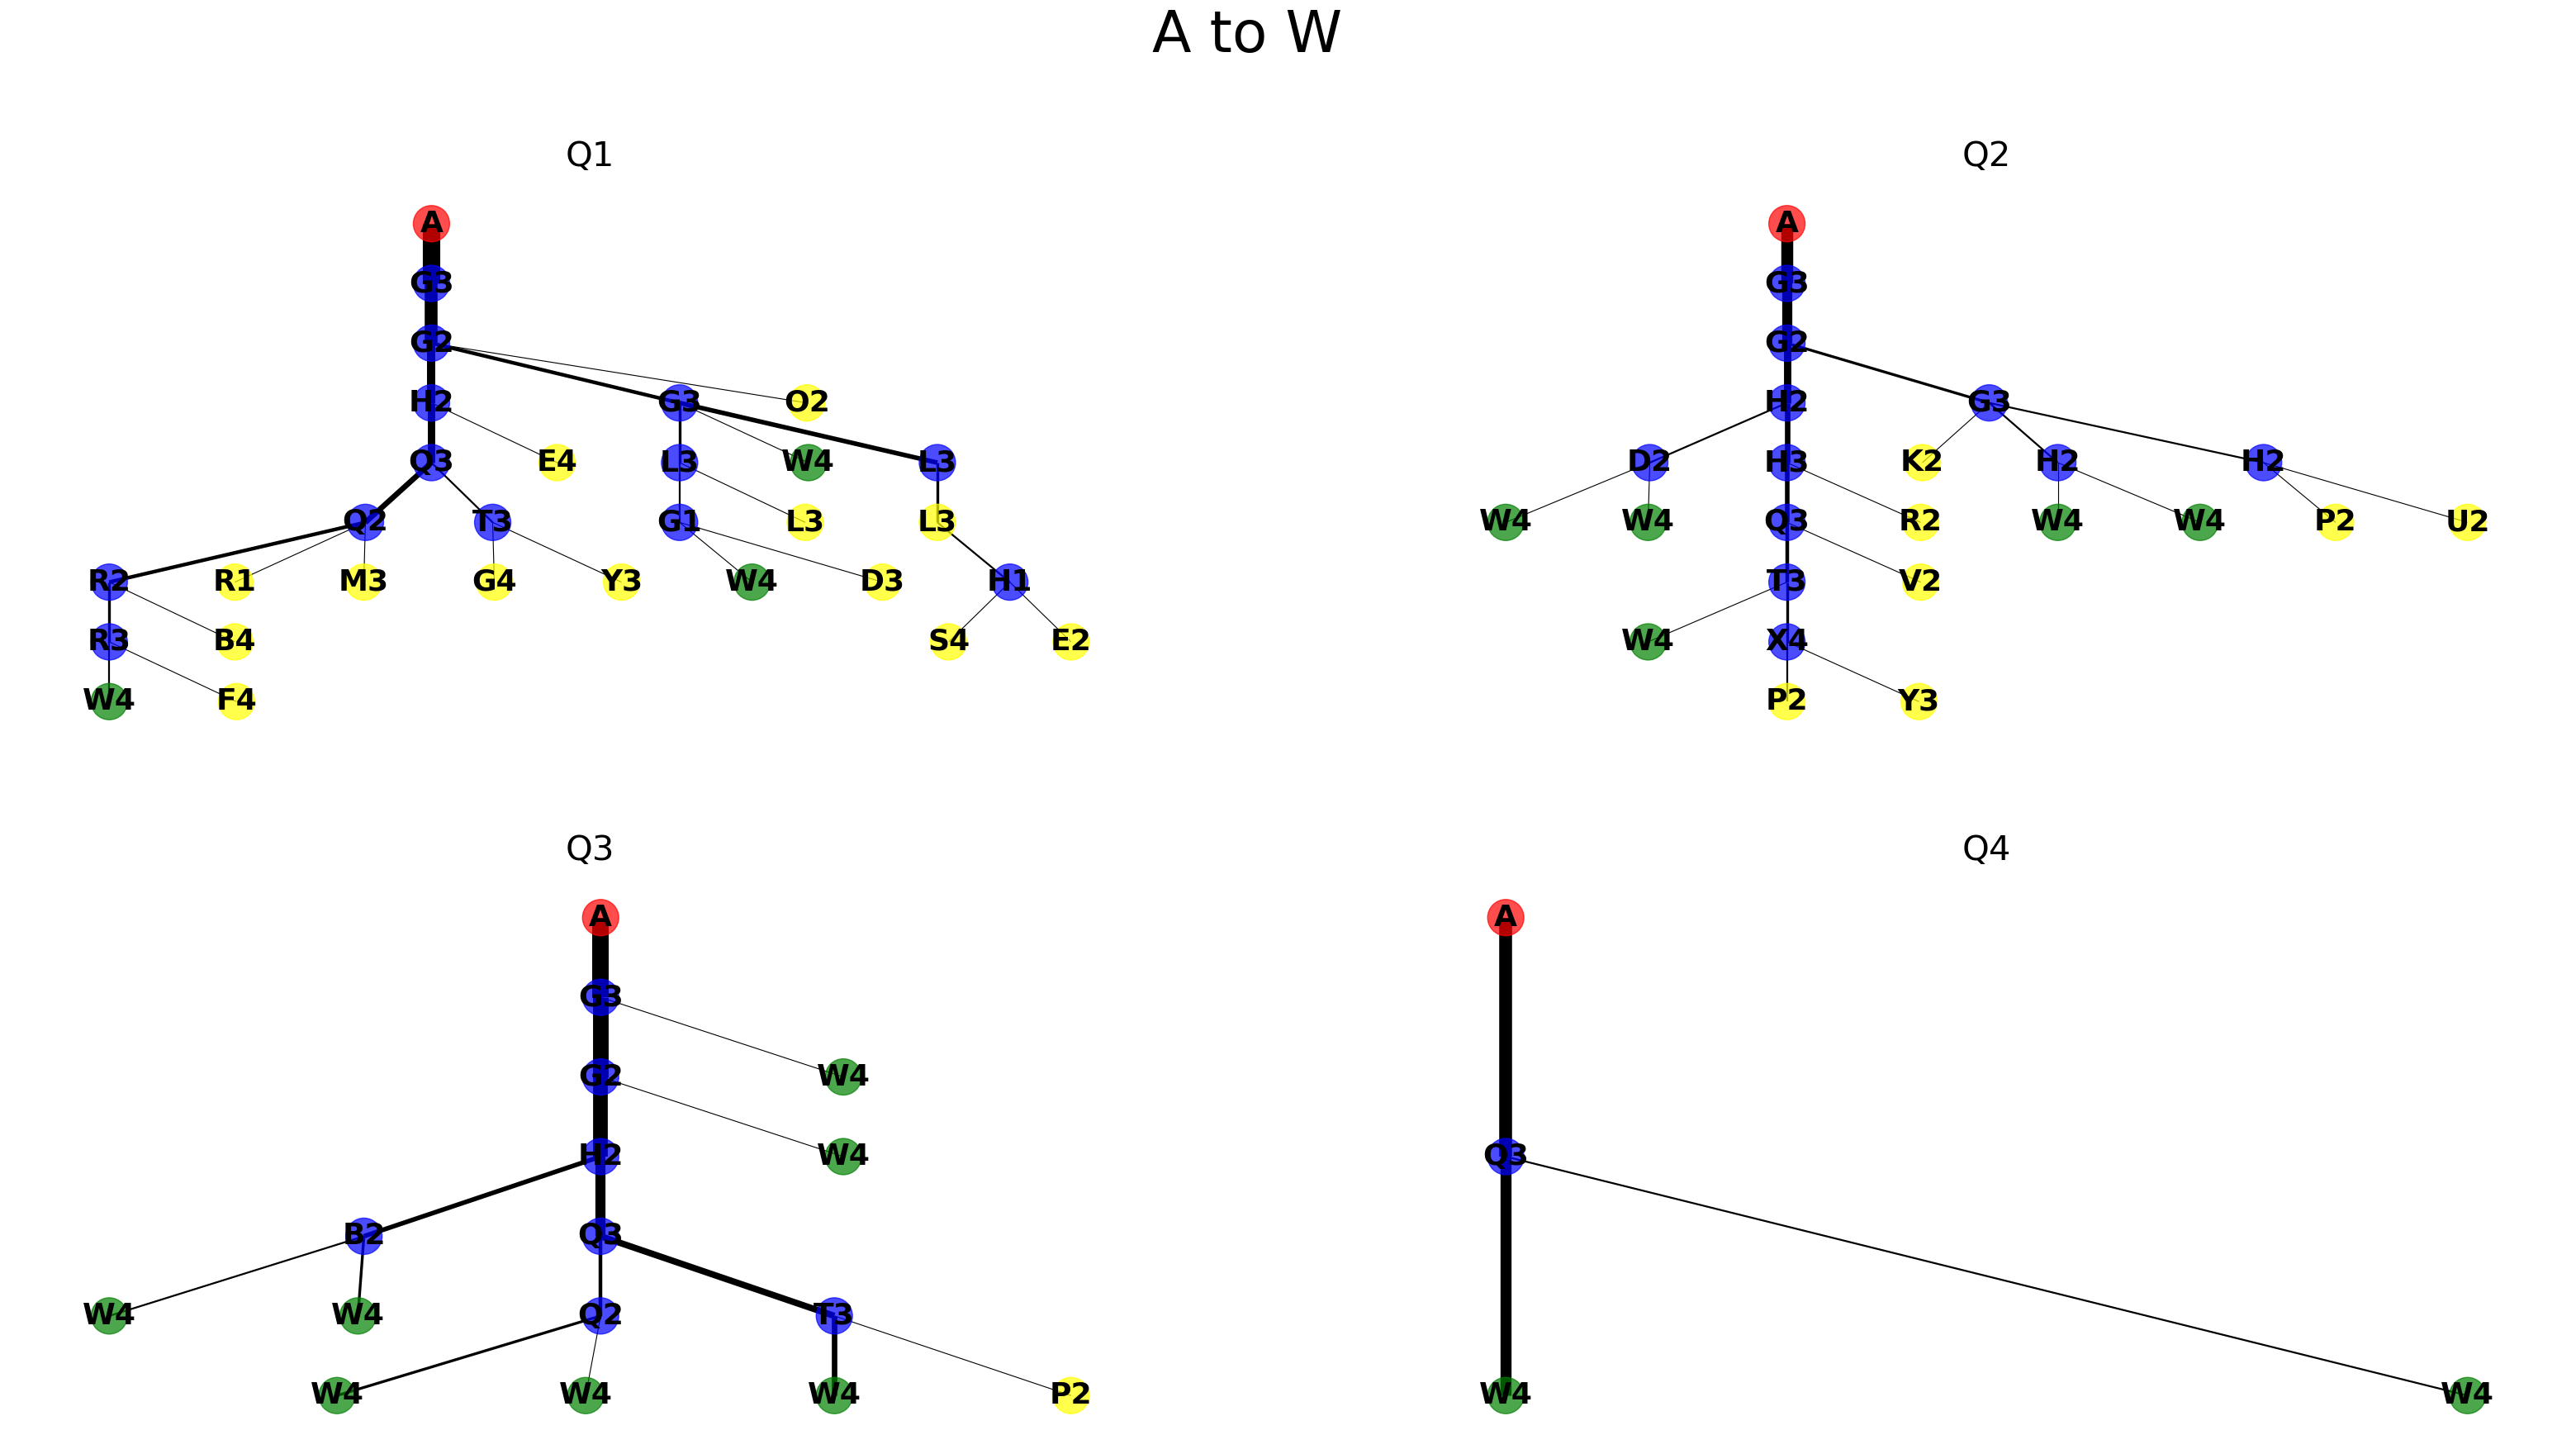

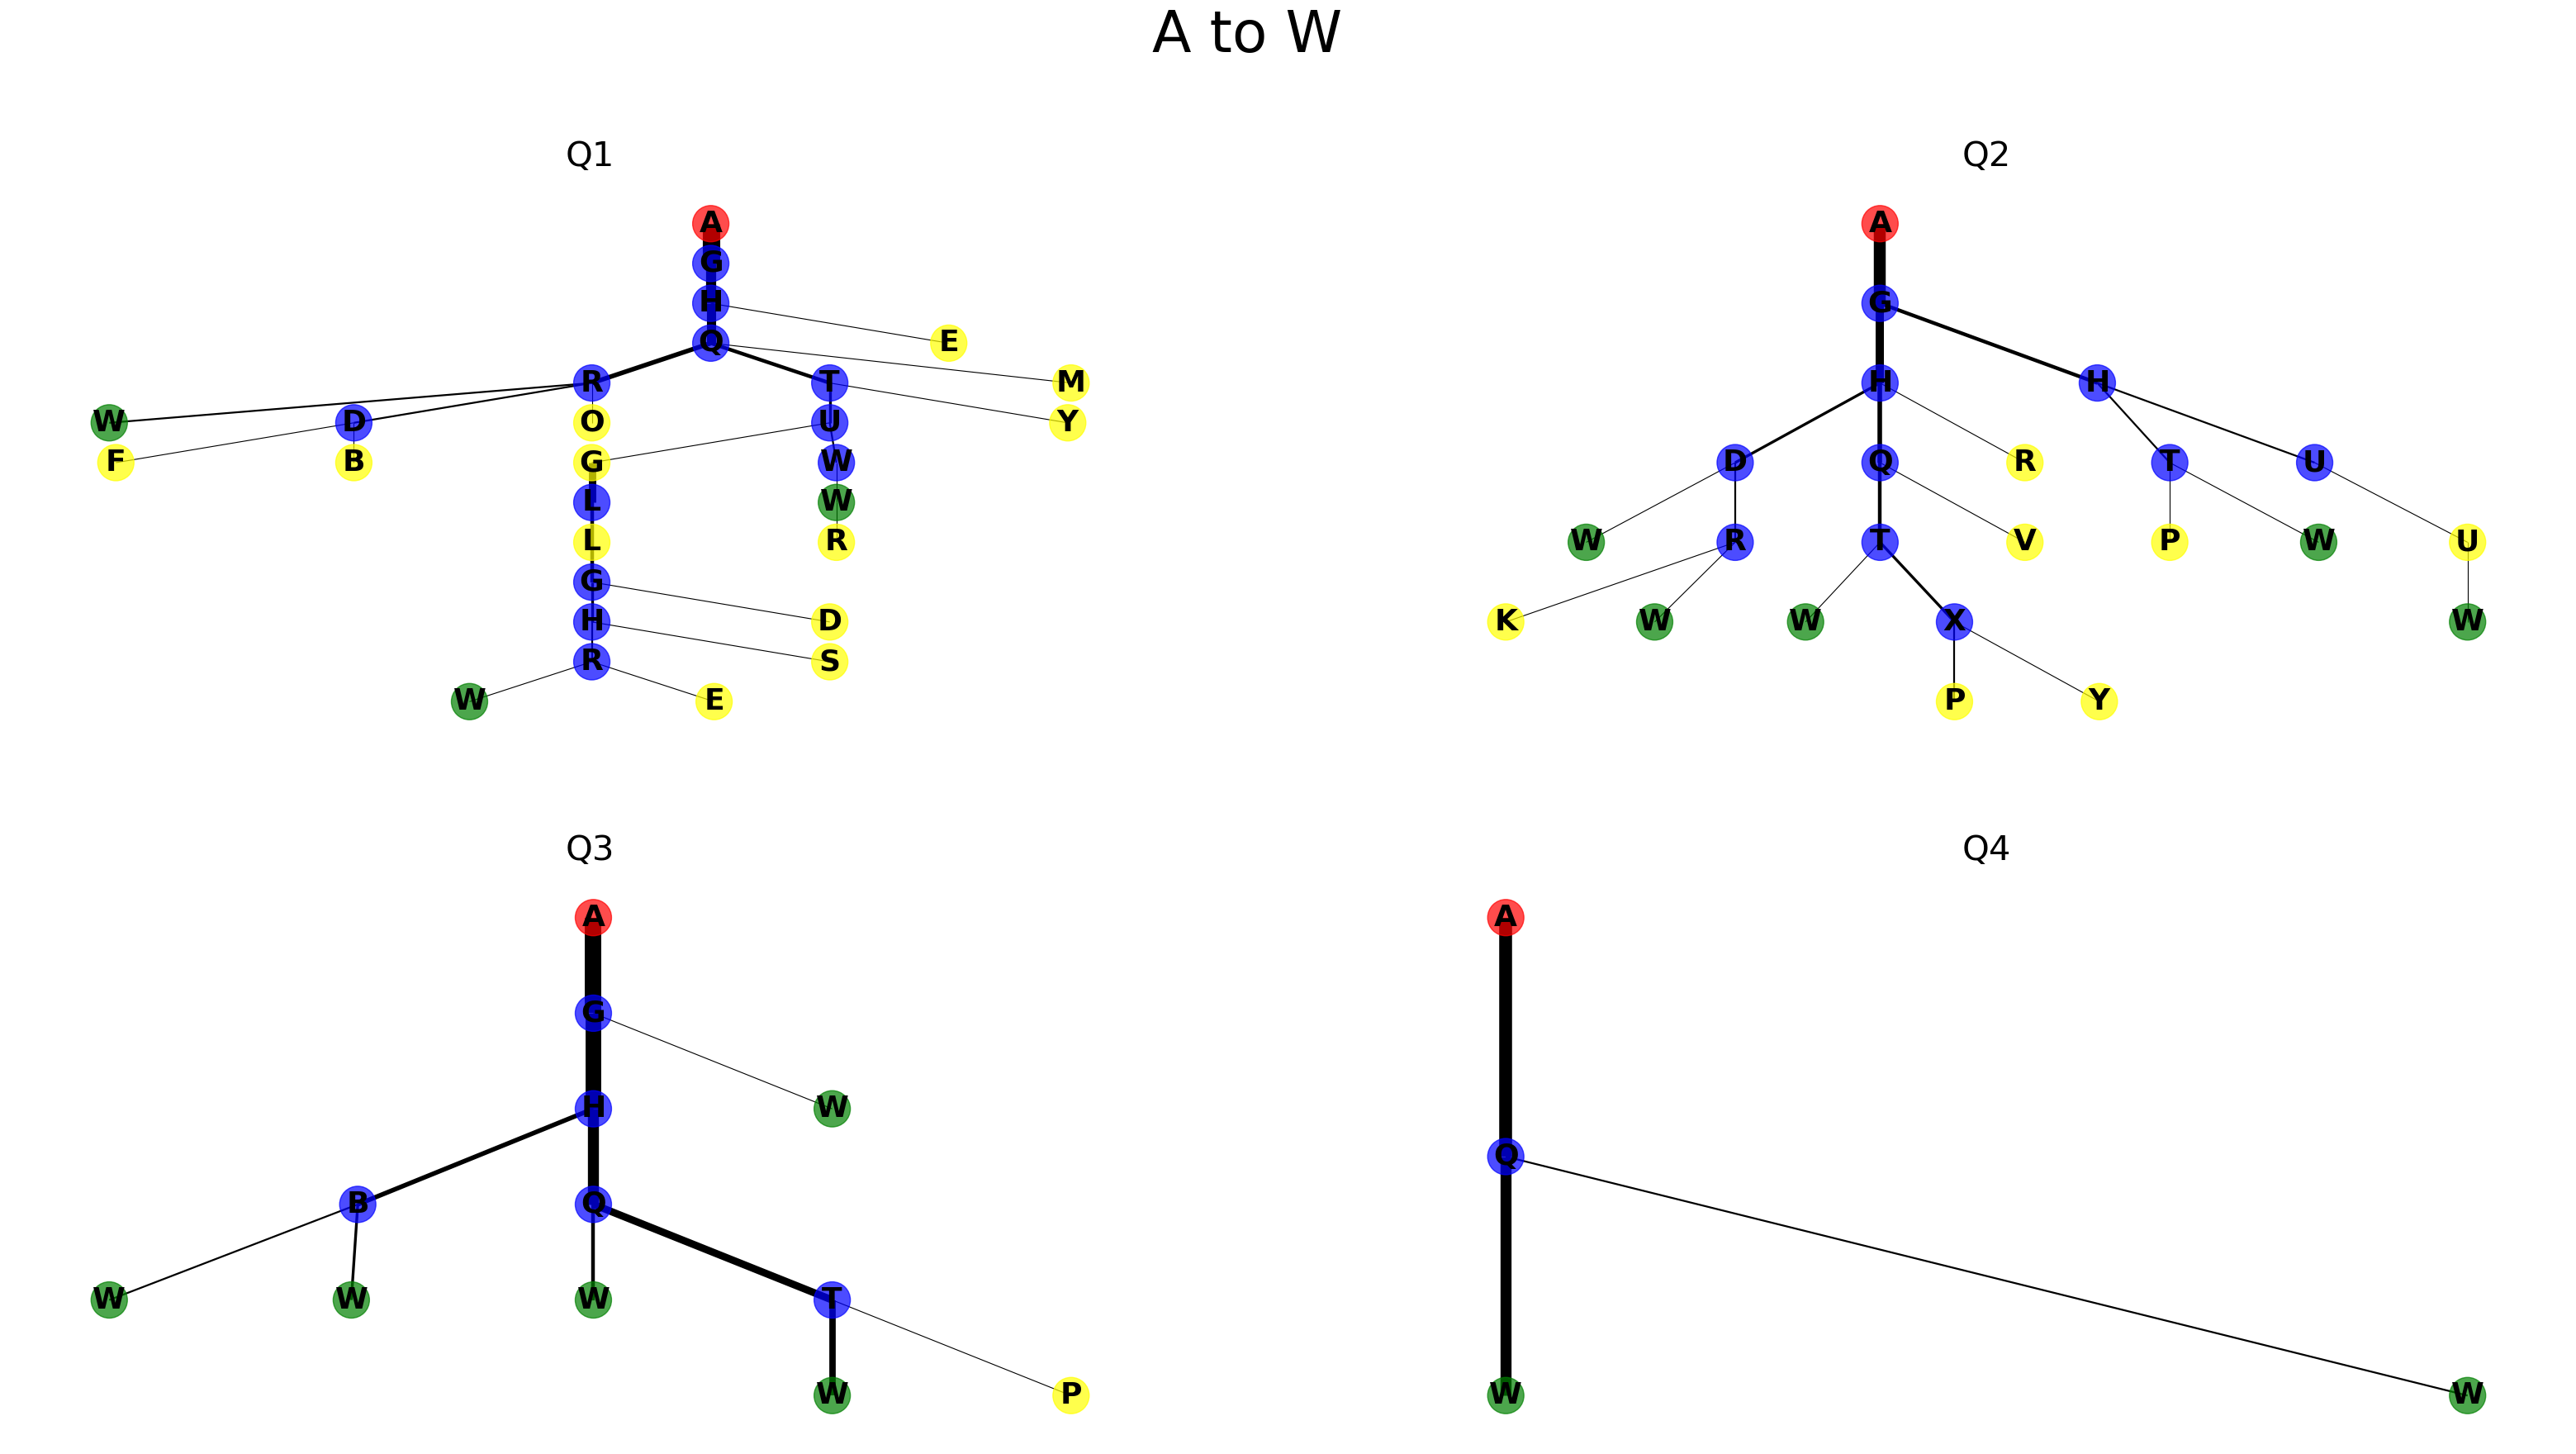

In [4]:
plot_quartile_reebs_for_start_end(test_df, "A", "W", save=False, use_turns=True)
plot_quartile_reebs_for_start_end(test_df, "A", "W", save=False, use_turns=False)

### Script to plot all start-end test reeb trees by quartile

In [5]:
if not os.path.exists("figures/testpath-reeb-by-quartile/"):
    # Create the directory
    os.makedirs("figures/testpath-reeb-by-quartile/")
    
# With turns
#   This makes reeb graph based on decisions, egocentric
for start_node, end_node in test_df.groupby(["StartAt", "EndAt"]).groups.keys():
    plot_quartile_reebs_for_start_end(test_df, start_node, end_node, save=True, use_turns=True)

# Ignoring turns -- trees should be simpler.
#   This is based on spatial path, allocentric
for start_node, end_node in test_df.groupby(["StartAt", "EndAt"]).groups.keys():
    plot_quartile_reebs_for_start_end(test_df, start_node, end_node, save=True, use_turns=False)

## Explore phase graphs

In [5]:
explore_df = df[~df["eprocs"].str.contains("Test")]

salient_node = "A"
person = explore_df["Subject"].unique()[0]
use_turns = False
path_str = "e_paths" if use_turns else "paths"

path = explore_df[explore_df["Subject"]==person][path_str].iloc[0]
G, num_trajs = do_reeb_for_explore_node(path, salient_node)

print(G.nodes)
print(G.edges)
print(f"This person has {num_trajs} paths starting at {salient_node}.")

['A_0', 'E_0', 'M_0', 'F_0']
[('A_0', 'E_0'), ('E_0', 'M_0'), ('E_0', 'F_0')]
This person has 2 paths starting at A.


### Plotting explore reeb

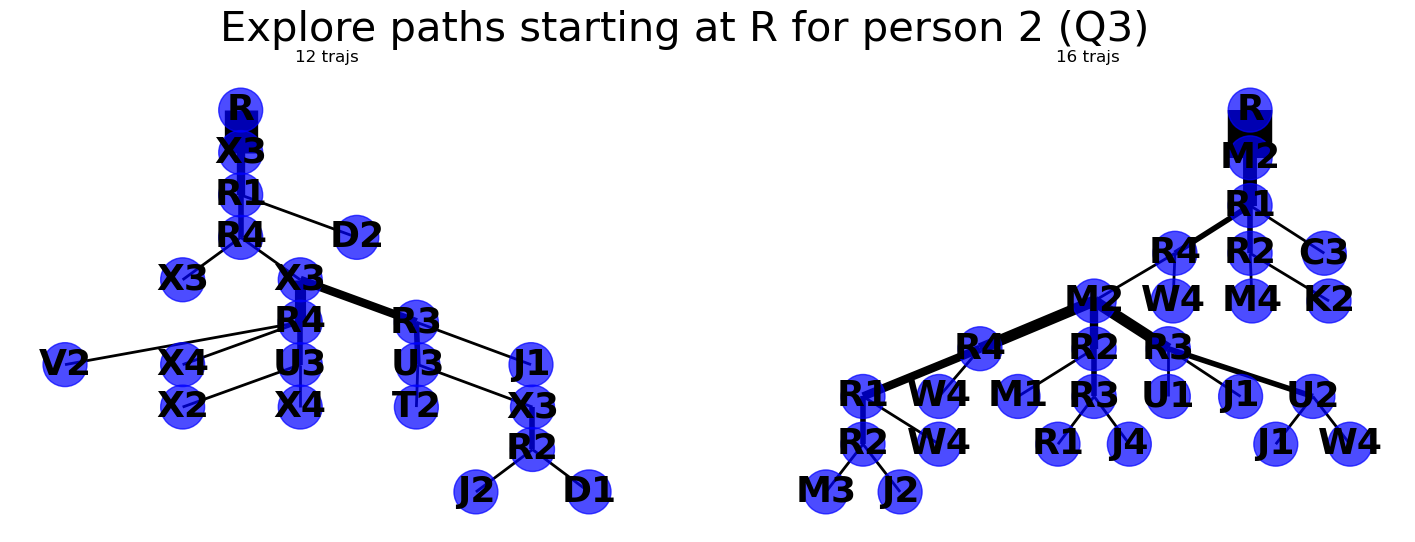

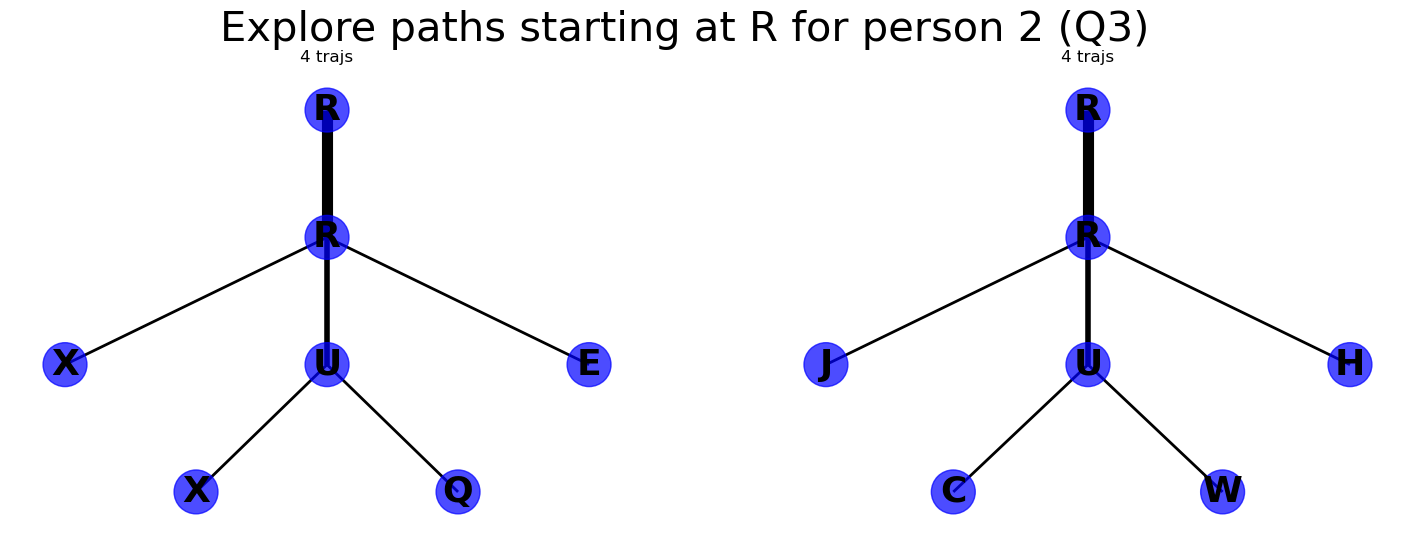

In [6]:
explore_df = df[~df["eprocs"].str.contains("Test")]

salient_node = "R"
person = explore_df["Subject"].unique()[0]
use_turns = False
path_str = "e_paths" if use_turns else "paths"
q = test_df[test_df["Subject"] == person]["quartile"].iloc[0]

plot_reeb_explore(explore_df, person, salient_node, q=q, save=False, use_turns=True)
plot_reeb_explore(explore_df, person, salient_node, q=q, save=False, use_turns=False)

### Script for generating all reeb explore graphs per node per person

A
B
C
D
E


KeyboardInterrupt: 

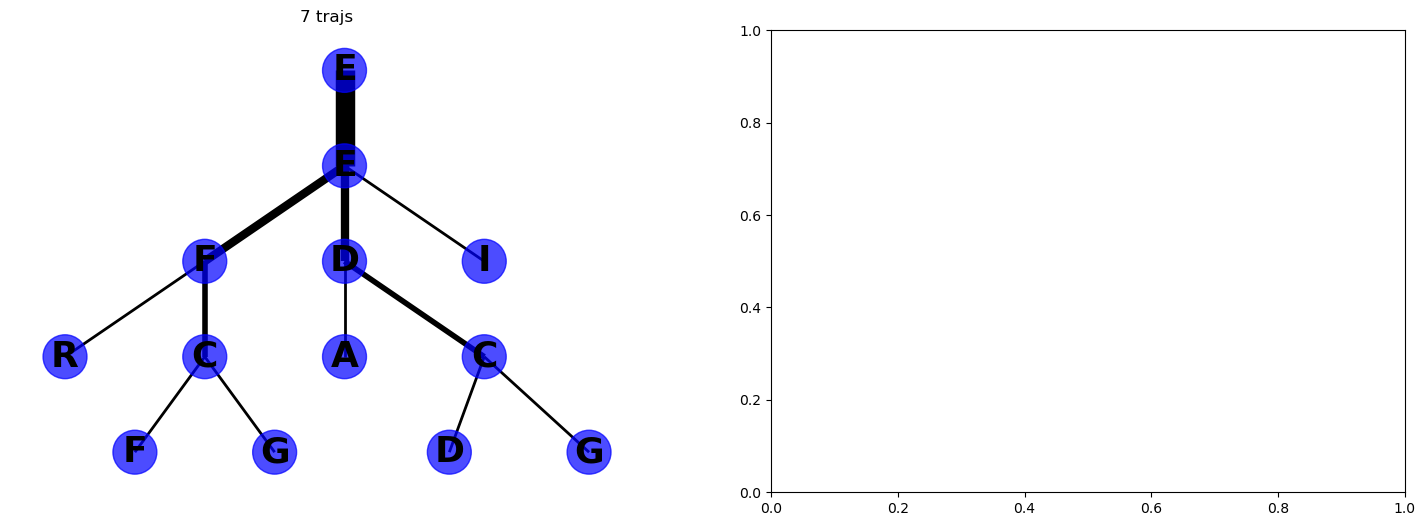

In [11]:
### RUN THIS TO GENERATE ALL EXPLORE REEBS FROM EACH NODE FOR EACH PERSON ###
# only do first 20 for tractability and space
explore_df = df[~df["eprocs"].str.contains("Test")]
for j, salient_node in enumerate("ABCDEFGHIJKLMNOPQRSTUVWXYZ"):
    print(salient_node)
    count = 0
    for subj in explore_df["Subject"].unique():
        if os.path.exists('figures/explore/starting_{salient_node}/subj_{subj}-NOTURN.png'):
            continue
        # print(subj,)
        qs = test_df[test_df["Subject"] == subj]["quartile"]
        if len(qs) > 0:
            q = qs.iloc[0]
            plot_reeb_explore(explore_df, subj, salient_node, q=q, save=True, use_turns=False)
        count += 1
        # if count == 20: break

## Other things

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


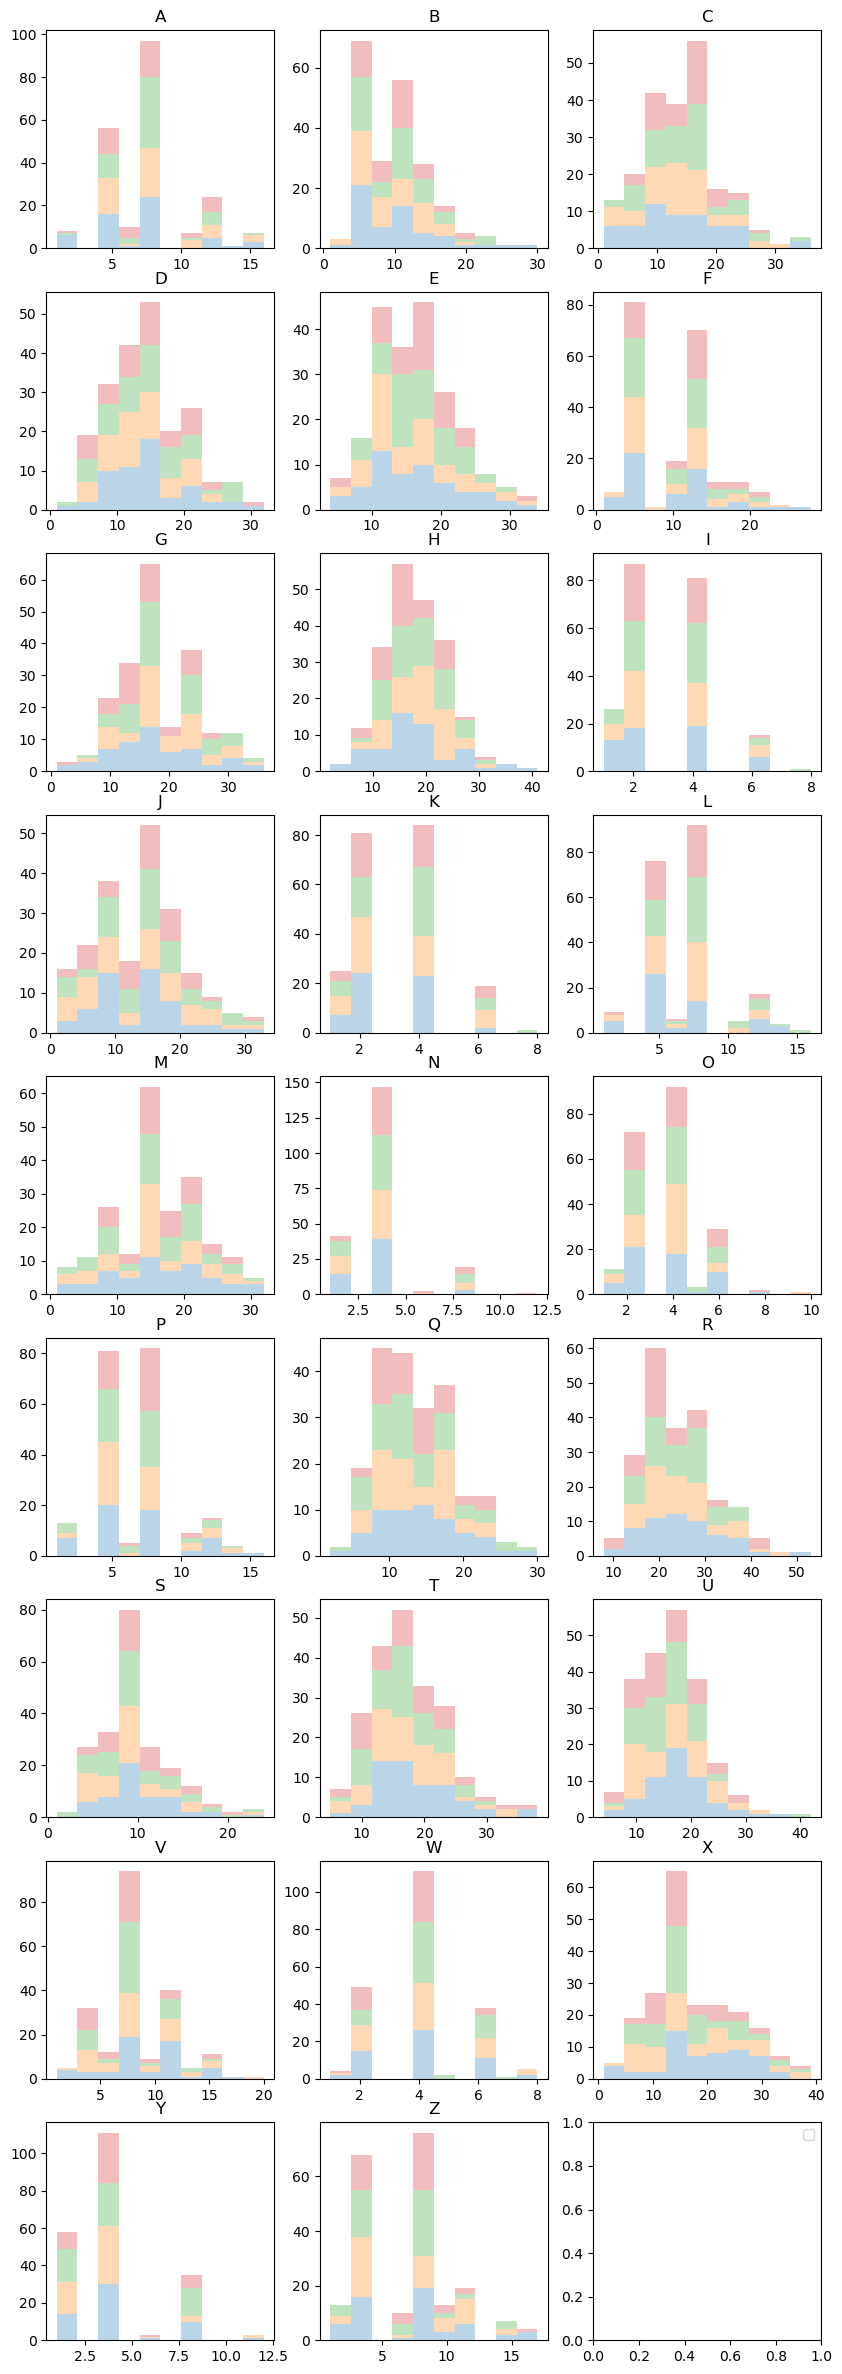

In [208]:
explore_df = df[~df["eprocs"].str.contains("Test")]

fig, axs = plt.subplots(9, 3, figsize=(10,30))
for j, salient_node in enumerate("ABCDEFGHIJKLMNOPQRSTUVWXYZ"):
    nnodes_by_q = {1: [], 2: [], 3: [], 4: []}
    for person in explore_df["Subject"].unique():
        qs = test_df[test_df["Subject"] == person]["quartile"]
        if len(qs) > 0:
            q = qs.iloc[0]
    
            for i, person_info in explore_df[explore_df["Subject"]==person].iterrows():
            
                path = person_info["e_paths"]
                # print(path)
                G = do_reeb_for_explore_node(path, salient_node)
                # print(G.nodes())
                n_nodes = len(G.nodes())
                nnodes_by_q[q].append(n_nodes)

    # for q in nnodes_by_q:
    #     axs[j//3][j%3].hist(nnodes_by_q[q], alpha=0.3, label=q, bins=[i for i in range(0,50,4)])
    #     # plt.xlim(0, 20)
    axs[j//3][j%3].set_title(salient_node)

    axs[j//3][j%3].hist([nnodes_by_q[q] for q in nnodes_by_q], alpha=0.3, label=q, stacked=True)#, bins=[i for i in range(0,50,4)])

plt.legend(loc="upper right")
plt.show()